# Q2: Hub Airport Delays

**Research Question:**  
Do delays originating from specific hub airports propagate more severely through the network than delays from non-hub airports?

**Notebook Purpose:**  
This notebook explores whether flights departing from hub airports show stronger delay patterns than flights departing from non-hub airports.

---

In [6]:
# Standard imports for Q2
from pathlib import Path
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

## Load Data

I start by loading the main flight dataset and the airport lookup table that will be used later for airport-level interpretation.


In [7]:
# Load the main datasets used in the Q2 analysis.

FLIGHTS_PATH = Path('../data/raw/archive/flights.csv')
AIRPORTS_PATH = Path('../data/raw/archive/airports.csv')

df = pd.read_csv(FLIGHTS_PATH, low_memory=False)
airports_df = pd.read_csv(AIRPORTS_PATH)

print(f"Flights dataset shape: {df.shape}")
print(f"Airports dataset shape: {airports_df.shape}")
df.head()

Flights dataset shape: (5819079, 31)
Airports dataset shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## Scrape Hub-Related Airport Data

To support the Q2 analysis, I scrape a simple airport table from Wikipedia that lists U.S. airports by commercial enplanements (number of passengers boarding plane). This gives an external reference for airport traffic volume and hub category, which can then be merged back into the flight data using airport codes.


In [13]:
# Scrape a hub-related airport table from Wikipedia.

WIKI_URL = 'https://en.wikipedia.org/wiki/List_of_the_busiest_airports_in_the_United_States'

headers = {
    'User-Agent': 'Mozilla/5.0'
}

tables = pd.read_html(WIKI_URL, storage_options=headers)
print(f"Number of tables found: {len(tables)}")

# The first matching airport table with IATA codes and a 2015 column is used (Large hubs).
scraped_hub_df = None
for table in tables:
    table.columns = [str(col).strip() for col in table.columns]
    normalized_columns = [str(col).replace('\n', ' ').replace('<br>', ' ').strip() for col in table.columns]
    table.columns = normalized_columns
    has_iata_code = any('iata' in col.lower() and 'code' in col.lower() for col in table.columns)
    has_2015 = any('2015' in str(col) for col in table.columns)

    if has_iata_code and has_2015:
        scraped_hub_df = table.copy()
        break

if scraped_hub_df is None:
    raise ValueError('Could not find a suitable airport table on the Wikipedia page.')

iata_col = next(col for col in scraped_hub_df.columns if 'iata' in col.lower() and 'code' in col.lower())
year_2015_col = next(col for col in scraped_hub_df.columns if '2015' in str(col))

scraped_hub_df = scraped_hub_df.rename(columns={
    iata_col: 'ORIGIN_AIRPORT',
    year_2015_col: 'SCRAPED_ENPLANEMENTS_2015'
})

airport_name_column = [col for col in scraped_hub_df.columns if 'Airport' in col]
if airport_name_column:
    scraped_hub_df = scraped_hub_df.rename(columns={airport_name_column[0]: 'SCRAPED_AIRPORT_NAME'})

# Every airport listed in this first table is treated as a hub airport.
scraped_hub_df['SCRAPED_HUB_CATEGORY'] = 'Hub'
scraped_hub_df = scraped_hub_df[['ORIGIN_AIRPORT', 'SCRAPED_HUB_CATEGORY', 'SCRAPED_ENPLANEMENTS_2015', 'SCRAPED_AIRPORT_NAME']].drop_duplicates()
scraped_hub_df.head()

Number of tables found: 10


,ORIGIN_AIRPORT,SCRAPED_HUB_CATEGORY,SCRAPED_ENPLANEMENTS_2015,SCRAPED_AIRPORT_NAME
0,ATL,Hub,49340732,Hartsfield–Jackson Atlanta International Airport
1,DFW,Hub,31589839,Dallas/Fort Worth International Airport
2,DEN,Hub,26280043,Denver International Airport
3,ORD,Hub,36305668,O'Hare International Airport
4,LAX,Hub,36351272,Los Angeles International Airport


## Research Framing

This section records the main design choices for the Q2 analysis so the comparison between hub and non-hub airports stays clear and consistent.


In [14]:
# Record the main assumptions and definitions used in the Q2 analysis.

q2_design = {
    'question': 'Do delays from hub airports propagate more severely than delays from non-hub airports?',
    'unit_of_analysis': 'Flights aggregated by origin airport and compared by hub status',
    'hub_definition': 'Hub status taken from the first scraped airport enplanement table on Wikipedia, with all airports in that table treated as hubs',
    'delay_measures': [
        'Average departure delay',
        'Average arrival delay',
        'Proportion of flights delayed by more than 15 minutes',
        'Cancellation rate',
        'A simple delay difference based on the difference between arrival and departure delay'
    ]
}

q2_design

{'question': 'Do delays from hub airports propagate more severely than delays from non-hub airports?',
 'unit_of_analysis': 'Flights aggregated by origin airport and compared by hub status',
 'hub_definition': 'Hub status taken from the first scraped airport enplanement table on Wikipedia, with all airports in that table treated as hubs',
 'delay_measures': ['Average departure delay',
  'Average arrival delay',
  'Proportion of flights delayed by more than 15 minutes',
  'Cancellation rate',
  'A simple delay difference based on the difference between arrival and departure delay']}

## Select Data

Only the fields needed for comparing origin-airport delay behaviour are kept here, so the analysis stays focused on the research question.


In [15]:
# Keep the columns needed for the Q2 comparison.

columns_to_keep = [
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'CANCELLED', 'DIVERTED', 'DISTANCE'
]
columns_to_keep = [col for col in columns_to_keep if col in df.columns]

df_selected = df[columns_to_keep].copy()
print(f"Shape after column selection: {df_selected.shape}")
print(columns_to_keep)

Shape after column selection: (5819079, 12)
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'CANCELLED', 'DIVERTED', 'DISTANCE']


## Prepare Data

The data is cleaned here in a lighter way than Q1 because this notebook is aimed at grouped comparison rather than predictive modelling.


In [16]:
# Filter the dataset and handle the main missing-value issues.

df_q2_base = df_selected.copy()
df_q2_base = df_q2_base[df_q2_base['DIVERTED'] == 0]
df_q2_base = df_q2_base.dropna(subset=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])

df_q2 = df_q2_base.dropna(subset=['DEPARTURE_DELAY']).copy()

if 'ARRIVAL_DELAY' in df_q2.columns:
    df_q2['ARRIVAL_DELAY'] = df_q2['ARRIVAL_DELAY'].fillna(df_q2['ARRIVAL_DELAY'].median())

print(f"Base Q2 table shape: {df_q2_base.shape}")
print(f"Delay-analysis table shape: {df_q2.shape}")

Base Q2 table shape: (5803892, 12)
Delay-analysis table shape: (5717739, 12)


In [17]:
# Remove exact duplicate rows before aggregation.

before_base = len(df_q2_base)
before_delay = len(df_q2)

df_q2_base = df_q2_base.drop_duplicates()
df_q2 = df_q2.drop_duplicates()

print(f"Removed {before_base - len(df_q2_base)} duplicate rows from the base table.")
print(f"Removed {before_delay - len(df_q2)} duplicate rows from the delay-analysis table.")

Removed 50259 duplicate rows from the base table.
Removed 27119 duplicate rows from the delay-analysis table.


In [18]:
# Create simple delay indicators for the hub and non-hub comparison.

df_q2['DELAY_15'] = (df_q2['DEPARTURE_DELAY'] > 15).astype(int)
df_q2['ARRIVAL_DELAY_15'] = (df_q2['ARRIVAL_DELAY'] > 15).astype(int)
df_q2['PROPAGATION_GAP'] = df_q2['ARRIVAL_DELAY'] - df_q2['DEPARTURE_DELAY']
df_q2_base['IS_CANCELLED'] = df_q2_base['CANCELLED'].astype(int)

df_q2[['DELAY_15', 'ARRIVAL_DELAY_15', 'PROPAGATION_GAP']].head()

,DELAY_15,ARRIVAL_DELAY_15,PROPAGATION_GAP
0,0,0,-11.0
1,0,0,-1.0
2,0,0,7.0
3,0,0,-4.0
4,0,0,-20.0


## Merge Scraped Hub Data

The scraped airport table is merged here so that hub status comes from the external source.


In [19]:
# Merge the scraped hub table into the Q2 data.

df_q2 = df_q2.merge(scraped_hub_df, on='ORIGIN_AIRPORT', how='left')
df_q2_base = df_q2_base.merge(scraped_hub_df, on='ORIGIN_AIRPORT', how='left')

df_q2['HUB_STATUS'] = np.where(df_q2['SCRAPED_HUB_CATEGORY'].fillna('Non-Hub') == 'Hub', 'Hub', 'Non-Hub')
df_q2_base['HUB_STATUS'] = np.where(df_q2_base['SCRAPED_HUB_CATEGORY'].fillna('Non-Hub') == 'Hub', 'Hub', 'Non-Hub')

df_q2[['ORIGIN_AIRPORT', 'SCRAPED_HUB_CATEGORY', 'SCRAPED_ENPLANEMENTS_2015', 'HUB_STATUS']].head()

,ORIGIN_AIRPORT,SCRAPED_HUB_CATEGORY,SCRAPED_ENPLANEMENTS_2015,HUB_STATUS
0,ANC,NaN,NaN,Non-Hub
1,LAX,Hub,36351272.0,Hub
2,SFO,Hub,24190560.0,Hub
3,LAX,Hub,36351272.0,Hub
4,SEA,Hub,20148980.0,Hub


## Integrate Airport Metadata

Airport metadata is joined here so later summaries and plots are easier to interpret.


In [20]:
# Merge airport metadata for origin airports.

origin_airports = airports_df.rename(columns={
    'IATA_CODE': 'ORIGIN_AIRPORT',
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE'
})

df_q2 = df_q2.merge(
    origin_airports[['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE']],
    on='ORIGIN_AIRPORT',
    how='left'
)

df_q2_base = df_q2_base.merge(
    origin_airports[['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE']],
    on='ORIGIN_AIRPORT',
    how='left'
)

df_q2.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY,CANCELLED,DIVERTED,DISTANCE,DELAY_15,ARRIVAL_DELAY_15,PROPAGATION_GAP,SCRAPED_HUB_CATEGORY,SCRAPED_ENPLANEMENTS_2015,SCRAPED_AIRPORT_NAME,HUB_STATUS,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE
0,2015,1,1,4,AS,ANC,SEA,-11.0,-22.0,0,0,1448,0,0,-11.0,NaN,NaN,NaN,Non-Hub,Ted Stevens Anchorage International Airport,Anchorage,AK
1,2015,1,1,4,AA,LAX,PBI,-8.0,-9.0,0,0,2330,0,0,-1.0,Hub,36351272.0,Los Angeles International Airport,Hub,Los Angeles International Airport,Los Angeles,CA
2,2015,1,1,4,US,SFO,CLT,-2.0,5.0,0,0,2296,0,0,7.0,Hub,24190560.0,San Francisco International Airport,Hub,San Francisco International Airport,San Francisco,CA
3,2015,1,1,4,AA,LAX,MIA,-5.0,-9.0,0,0,2342,0,0,-4.0,Hub,36351272.0,Los Angeles International Airport,Hub,Los Angeles International Airport,Los Angeles,CA
4,2015,1,1,4,AS,SEA,ANC,-1.0,-21.0,0,0,1448,0,0,-20.0,Hub,20148980.0,Seattle–Tacoma International Airport,Hub,Seattle-Tacoma International Airport,Seattle,WA


## Build Aggregated Analysis Tables

The prepared dataset is aggregated here so hub and non-hub airports can be compared more clearly.


In [21]:
# Create grouped summaries for the hub and non-hub comparison.

delay_summary = (
    df_q2.groupby('HUB_STATUS')
    .agg(
        flights=('ORIGIN_AIRPORT', 'size'),
        avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
        avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
        departure_delay_rate=('DELAY_15', 'mean'),
        arrival_delay_rate=('ARRIVAL_DELAY_15', 'mean'),
        avg_propagation_gap=('PROPAGATION_GAP', 'mean')
    )
)

cancellation_summary = (
    df_q2_base.groupby('HUB_STATUS')
    .agg(cancellation_rate=('IS_CANCELLED', 'mean'))
)

hub_summary = delay_summary.join(cancellation_summary).sort_values('avg_departure_delay', ascending=False)
hub_summary

,flights,avg_departure_delay,avg_arrival_delay,departure_delay_rate,arrival_delay_rate,avg_propagation_gap,cancellation_rate
HUB_STATUS,,,,,,,
Hub,3550526,10.592183,5.244380,0.194239,0.193529,-5.347803,0.011352
Non-Hub,2140094,7.378722,3.171241,0.151246,0.157042,-4.207481,0.012011


In [22]:
# Create an airport-level summary for deeper inspection.

airport_summary = (
    df_q2.groupby(['ORIGIN_AIRPORT', 'HUB_STATUS'])
    .agg(
        flights=('ORIGIN_AIRPORT', 'size'),
        avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
        avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
        departure_delay_rate=('DELAY_15', 'mean'),
        avg_propagation_gap=('PROPAGATION_GAP', 'mean')
    )
    .reset_index()
    .sort_values(['HUB_STATUS', 'avg_departure_delay'], ascending=[True, False])
)

airport_summary.head(20)

,ORIGIN_AIRPORT,HUB_STATUS,flights,avg_departure_delay,avg_arrival_delay,departure_delay_rate,avg_propagation_gap
534,ORD,Hub,276082,14.162709,8.646507,0.236759,-5.516202
412,EWR,Hub,98127,13.653123,4.533543,0.230803,-9.119580
357,BWI,Hub,84046,13.353366,7.308188,0.237620,-6.045178
488,LGA,Hub,94514,13.289460,5.701378,0.220740,-7.588082
501,MDW,Hub,78436,12.857910,6.113417,0.239074,-6.744492
455,IAD,Hub,33635,12.773956,5.198573,0.201130,-7.575383
509,MIA,Hub,68037,12.509884,7.111792,0.226186,-5.398092
472,JFK,Hub,91532,12.106498,3.636630,0.201842,-8.469868
499,MCO,Hub,109045,12.067385,7.035600,0.202522,-5.031785
391,DEN,Hub,193071,11.820289,7.219614,0.220152,-4.600675


## Explore and Visualise Results

These charts compare delay behaviour between hub and non-hub origin airports, including a simple downstream propagation proxy.


C:\Users\anasa\AppData\Local\Temp\ipykernel_32520\2756965039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='avg_departure_delay', palette='Set2')


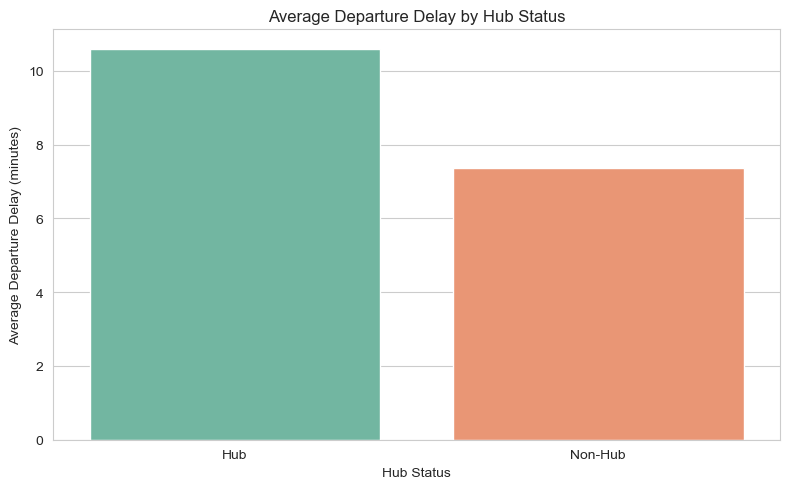

In [23]:
# Plot average departure delay by hub status.

plt.figure(figsize=(8, 5))
sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='avg_departure_delay', palette='Set2')
plt.title('Average Departure Delay by Hub Status')
plt.xlabel('Hub Status')
plt.ylabel('Average Departure Delay (minutes)')
plt.tight_layout()
plt.show()

C:\Users\anasa\AppData\Local\Temp\ipykernel_32520\287810969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='departure_delay_rate', palette='Set1')


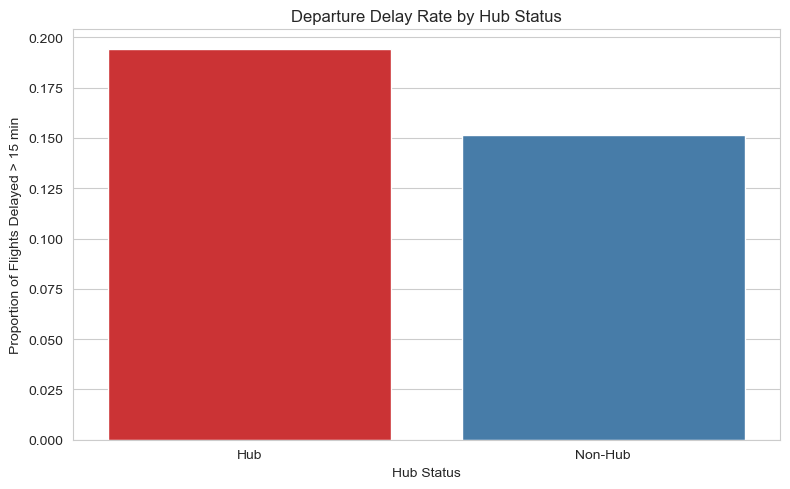

In [24]:
# Plot the proportion of flights delayed by more than 15 minutes.

plt.figure(figsize=(8, 5))
sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='departure_delay_rate', palette='Set1')
plt.title('Departure Delay Rate by Hub Status')
plt.xlabel('Hub Status')
plt.ylabel('Proportion of Flights Delayed > 15 min')
plt.tight_layout()
plt.show()

C:\Users\anasa\AppData\Local\Temp\ipykernel_32520\2812784995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='avg_propagation_gap', palette='Set3')


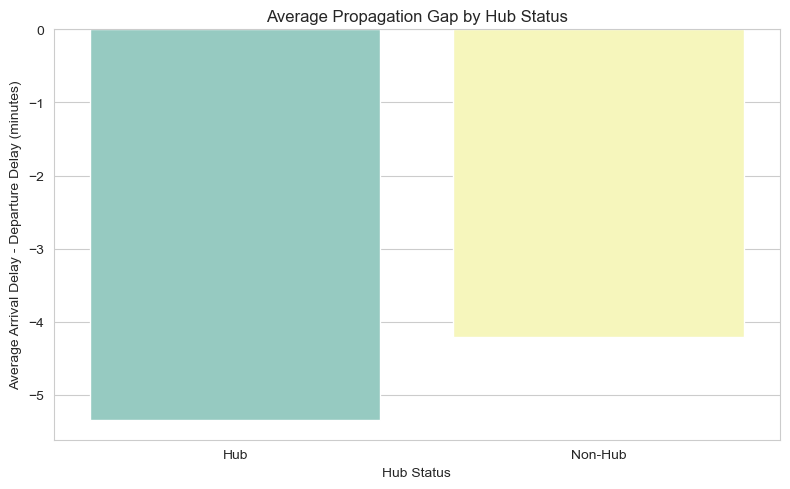

In [25]:
# Plot the average propagation gap by hub status.

plt.figure(figsize=(8, 5))
sns.barplot(data=hub_summary.reset_index(), x='HUB_STATUS', y='avg_propagation_gap', palette='Set3')
plt.title('Average Propagation Gap by Hub Status')
plt.xlabel('Hub Status')
plt.ylabel('Average Arrival Delay - Departure Delay (minutes)')
plt.tight_layout()
plt.show()

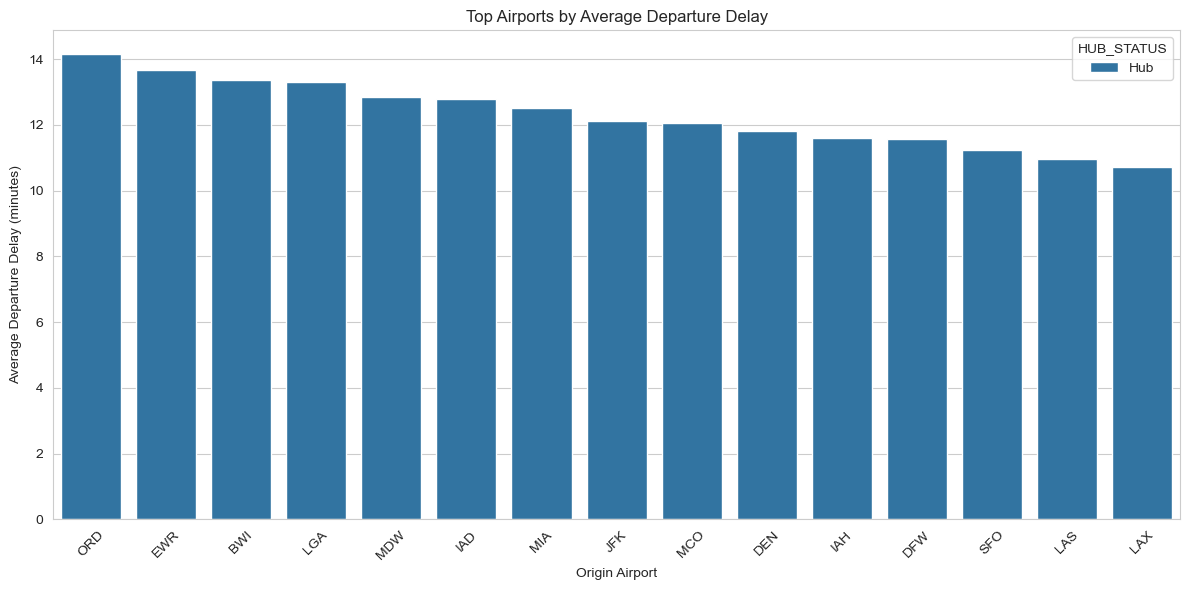

In [26]:
# Compare the highest-delay airports in the filtered summary table.

top_airports_plot = airport_summary[airport_summary['flights'] >= 5000].head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_airports_plot, x='ORIGIN_AIRPORT', y='avg_departure_delay', hue='HUB_STATUS')
plt.title('Top Airports by Average Departure Delay')
plt.xlabel('Origin Airport')
plt.ylabel('Average Departure Delay (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpret Findings

This section records the main findings from the hub and non-hub comparison and links them back to the research question.


In [29]:
# Record the main findings from the Q2 analysis.

hub_departure_delay = hub_summary.loc['Hub', 'avg_departure_delay']
non_hub_departure_delay = hub_summary.loc['Non-Hub', 'avg_departure_delay']
hub_delay_rate = hub_summary.loc['Hub', 'departure_delay_rate']
non_hub_delay_rate = hub_summary.loc['Non-Hub', 'departure_delay_rate']
hub_cancellation_rate = hub_summary.loc['Hub', 'cancellation_rate']
non_hub_cancellation_rate = hub_summary.loc['Non-Hub', 'cancellation_rate']
hub_propagation_gap = hub_summary.loc['Hub', 'avg_propagation_gap']
non_hub_propagation_gap = hub_summary.loc['Non-Hub', 'avg_propagation_gap']

top_airport = airport_summary.sort_values('avg_departure_delay', ascending=False).iloc[0]

q2_findings = [
    f"Hub airports recorded an average departure delay of {hub_departure_delay:.2f} minutes, compared with {non_hub_departure_delay:.2f} minutes for non-hub airports.",
    f"The proportion of flights delayed by more than 15 minutes was {hub_delay_rate:.2%} for hub airports and {non_hub_delay_rate:.2%} for non-hub airports.",
    f"Cancellation rates were {hub_cancellation_rate:.2%} for hub airports and {non_hub_cancellation_rate:.2%} for non-hub airports.",
    f"The average propagation gap, measured as arrival delay minus departure delay, was {hub_propagation_gap:.2f} minutes for hub airports and {non_hub_propagation_gap:.2f} minutes for non-hub airports.",
    f"The airport with the highest average departure delay in the airport-level summary was {top_airport['ORIGIN_AIRPORT']} ({top_airport['HUB_STATUS']}) with an average delay of {top_airport['avg_departure_delay']:.2f} minutes.",
]

for i, finding in enumerate(q2_findings, 1):
    print(f"{i}. {finding}")

1. Hub airports recorded an average departure delay of 10.59 minutes, compared with 7.38 minutes for non-hub airports.
2. The proportion of flights delayed by more than 15 minutes was 19.42% for hub airports and 15.12% for non-hub airports.
3. Cancellation rates were 1.14% for hub airports and 1.20% for non-hub airports.
4. The average propagation gap, measured as arrival delay minus departure delay, was -5.35 minutes for hub airports and -4.21 minutes for non-hub airports.
5. The airport with the highest average departure delay in the airport-level summary was 14222 (Non-Hub) with an average delay of 89.11 minutes.


## Save Outputs

The key summary tables are saved here so they can be reused later in the report, presentation, or poster.


In [28]:
# Save the main Q2 summary tables.

OUTPUT_DIR = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

hub_summary.to_csv(OUTPUT_DIR / 'q2_hub_summary.csv')
airport_summary.to_csv(OUTPUT_DIR / 'q2_airport_summary.csv', index=False)
scraped_hub_df.to_csv(OUTPUT_DIR / 'q2_scraped_hub_table.csv', index=False)

print('Q2 summary tables saved.')

Q2 summary tables saved.
